# Clustering Lab

 
Based of the amazing work you did in the Movie Industry you've been recruited to the NBA! You are working as the VP of Analytics that helps support a head scout, Mr. Rooney, for the worst team in the NBA probably the Wizards. Mr. Rooney just heard about Data Science and thinks it can solve all the team's problems!!! He wants you to figure out a way to find players that are high performing but maybe not highly paid that you can steal to get the team to the playoffs! 

In this document you will work through a similar process that we did in class with the NBA data files will be in the canvas assignment, merging them together.

Details: 

- Determine a way to use clustering to estimate based on performance if 
players are under or over paid, generally. 

- Then select players you believe would be best for your team and explain why. Do so in three categories: 
    * Examples that are not good choices (3 or 4) 
    * Several options that are good choices (3 or 4)
    * Several options that could work, assuming you can't get the players in the good category (3 or 4)

- You will decide the cutoffs for each category, so you should be able to explain why you chose them.

- Provide a well commented and clean report of your findings in a separate notebook that can be presented to Mr. Rooney, keeping in mind he doesn't understand...anything. Include a rationale for variables you included in the model, details on your approach and a overview of the results with supporting visualizations. 


Hints:

- Salary is the variable you are trying to understand 
- When interpreting you might want to use graphs that include variables that are the most correlated with Salary
- You'll need to scale the variables before performing the clustering
- Be specific about why you selected the players that you did, more detail is better
- Use good coding practices, comment heavily, indent, don't use for loops unless totally necessary and create modular sections that align with some outcome. If necessary create more than one script,list/load libraries at the top and don't include libraries that aren't used. 
- Be careful for non-traditional characters in the players names, certain graphs won't work when these characters are included.


 salarie should be serpated by color, like a heatmap, slares wont be x and y axis tho
 shaped should be the cluster
need to figure out what features is the best to put on x and y scatter plot
so bsacilly need like skill performance levels and good high stats for the x and y
   expierennt but theres a mathamatical way to do. use stat like points scored, minutes played or games played, rebounds 
   these work well becase they have high distributiona dn varince beasucase they shows good from bad and makes better clusters
    tool to show how features that show salaries well: correlation matrix, which shows how features are correlated with each other and with the target variable (salaries)
       putting data on a chart to see how it moves in space. when slareis go up, which stats go up. run simple line?
if theres players at the top right but have low salraies then we want those guys
if there are players with high salaries but low stats then we want to avoid those guys


In [1]:
# Install Packages
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Load Data
salaries = pd.read_csv('2025_salaries.csv', header = 1, encoding = 'latin-1')
# the actual headers were in the second row of the csv file, so set header = 1
salaries.columns = ['Player', 'Team', 'Salary']
#change column names

nba = pd.read_csv('nba_2025.txt', sep=',', encoding = 'latin-1')
#this was a txt file not csv, but was still ceperated by commas, so set sep = ','

In [3]:
#Merging the datasets by the players name
merged = pd.merge(nba, salaries, on='Player', how = 'inner')
# went from salaries 471 and nba 643 down to merged having 524 rows bc there were dupliactes

In [4]:
#Drop variables that will not be needed or are duplicates
duplicates = merged[merged.duplicated(subset='Player', keep=False)]
#index then create a new dataframe with only the duplicates to show the duplicates
#there are 56 distinct players
#there are two cases for the duplcates:
   #1) a player was on more then one team during the season so thay had one row
   # for there combined data in 2TM, then two more rows for there spesfic stats on each spesfic team
   # 2) a player was on one team but when the datasets were merged there teams were listed differently
   # so they were not merged together and instead created two rows for the same player with the same stats but different team names
#my appraoch is to keep the first row for each player name beasuce teh 2TM row is alwasy first and
# the direct duplicates have teh same data in both rows so it does not matter which one i keep

In [5]:
#drop duplcaites by keeping first row for each player name
merged_dropped = merged.drop_duplicates(subset='Player', keep='first')


In [6]:
#check to see if there are any duplicates left
duplicates2 = merged_dropped[merged_dropped.duplicated(subset='Player', keep=False)]
#theres not any duplicates left

In [7]:
#print info to look at what rows need to be dropped and what columns types need to be changed
print(merged_dropped.columns)
print(merged_dropped.dtypes)
print(merged_dropped.isnull().sum())

Index(['Rk', 'Player', 'Age', 'Team_x', 'Pos', 'G', 'GS', 'MP', 'FG', 'FGA',
       'FG%', '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%', 'FT', 'FTA',
       'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS',
       'Trp-Dbl', 'Awards', 'Player-additional', 'Team_y', 'Salary'],
      dtype='str')
Rk                   float64
Player                   str
Age                  float64
Team_x                   str
Pos                      str
G                    float64
GS                   float64
MP                   float64
FG                   float64
FGA                  float64
FG%                  float64
3P                   float64
3PA                  float64
3P%                  float64
2P                   float64
2PA                  float64
2P%                  float64
eFG%                 float64
FT                   float64
FTA                  float64
FT%                  float64
ORB                  float64
DRB                  float64
TRB             

In [8]:
#drop unneccesary columns
df = merged_dropped.drop(columns=['Team_x', 'Player-additional', 'Awards', 'Team_y'])
#make salary numeric
df['Salary'] = df['Salary'].str.replace('$', '').str.replace(',', '').astype(float)

print(df.isnull().sum())

Rk          0
Player      0
Age         0
Pos         0
G           0
GS          0
MP          0
FG          0
FGA         0
FG%         0
3P          0
3PA         0
3P%        20
2P          0
2PA         0
2P%         1
eFG%        0
FT          0
FTA         0
FT%         3
ORB         0
DRB         0
TRB         0
AST         0
STL         0
BLK         0
TOV         0
PF          0
PTS         0
Trp-Dbl     0
Salary      3
dtype: int64


In [9]:
#drop the rows with missing salary data
df = df.dropna(subset=['Salary'])
#drop these columns beucase they are redundent anyway becuase its a percetage caluataled form data thats already there
df = df.drop(columns=['2P%','3P%','FT%'])

In [10]:
# search for the best features to use based on high varience and coorelation
#looking at variation
df[['PTS','AST','TRB','MP','STL','BLK']].var()

PTS    110377.011157
AST      7536.503199
TRB     13336.261682
MP     267976.714866
STL       446.733535
BLK       346.129618
dtype: float64

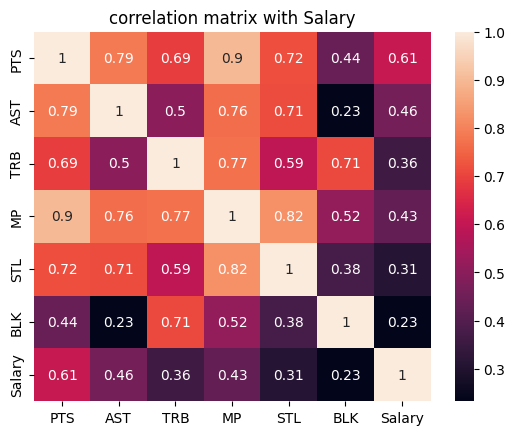

In [11]:
corrlation = df[['PTS','AST','TRB','MP','STL','BLK','Salary']].corr()

sns.heatmap(corrlation, annot=True) #shows number labels
plt.title("correlation matrix with Salary")
plt.show()

#I chose PTS and AST because they have the highest correlation numbers with Salary (0.61 and 0.46). I didn't use MP even though it also had a higher correlation with Salary because it's 0.90 correlated with points, which is redundant.

In [12]:
#scale the data 
from sklearn.preprocessing import StandardScaler

features = df[['PTS','AST','TRB','MP','STL','BLK']]
scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)

In [13]:
#Run the clustering algo with your best guess for K

# Im gonna do K=3. I dont know much about basketball but maybe having a group of the best, the middle, adn the worst
# players will be a good start and then can adjust from there.
# first trying out players PTS poinst scored and AST assists to show how they score but also play as a team member.
# Initialize KMeans with K=3
model = KMeans(n_clusters=3, random_state=1)
# fit
model.fit(scaled_data)
# add the cluster labels to the data frame
df['cluster'] = model.labels_

In [14]:
#View the results

# this gives the avg points and total assists for each cluster 
print(df.groupby("cluster")[["PTS", "AST"]].mean())

                PTS         AST
cluster                        
0        424.540881   92.754717
1        120.580000   27.973333
2        862.058824  198.382353


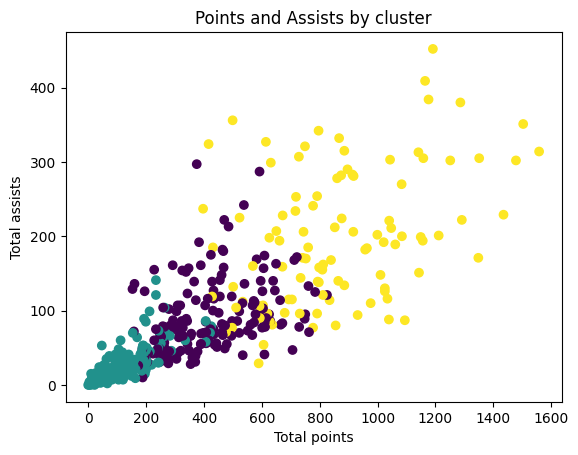

In [15]:
#Create a visualization of the results with 2 or 3 variables that you think will best
#differentiate the clusters

plt.scatter(df['PTS'], df['AST'], c=df['cluster'])
plt.xlabel('Total points')
plt.ylabel('Total assists')
plt.title('Points and Assists by cluster')
plt.show()

In [17]:
#Evaluate the quality of the clustering using total variance explained and silhouette scores
from sklearn.metrics import silhouette_score

# 1. Get the Silhouette Score
# 'kmeans' is your trained model, 'scaled_features' is your X and Y data
score = silhouette_score(scaled_data, model.labels_)
print(f"Silhouette Score: {score:.3f}")

# 2. Total Variance Explained (Inertia)
print(f"Inertia (Within-cluster sum of squares): {model.inertia_:.2f}")

Silhouette Score: 0.360
Inertia (Within-cluster sum of squares): 936.17


In [ ]:
#Determine the ideal number of clusters using the elbow method and the silhouette coefficient

In [ ]:
#Visualize the results of the elbow method

In [ ]:
#Use the brecommended number of cluster (assuming it's different) to retrain your model and visualize the results

In [ ]:
#Once again evaluate the quality of the clustering using total variance explained and silhouette scores

In [ ]:
#Use the model to select players for Mr. Rooney to consider

#Write up the results in a separate notebook with supporting visualizations and 
an overview of how and why you made the choices you did. This should be at least 
500 words and should be written for a non-technical audience.